In [1]:
import pandas as pd

# Conditional filtering

In [2]:
import numpy as np

In [8]:
df = pd.read_csv(r'C:\Users\Futurense\Downloads\movie.csv',index_col='title')
df.columns

Index(['year', 'color', 'content_rating', 'duration', 'director_name',
       'director_fb', 'actor1', 'actor1_fb', 'actor2', 'actor2_fb', 'actor3',
       'actor3_fb', 'gross', 'genres', 'num_reviews', 'num_voted_users',
       'plot_keywords', 'language', 'country', 'budget', 'imdb_score'],
      dtype='object')

In [ ]:
#select year,content and duration between lion king and little prince

In [12]:
#rows between the lion king movie to little prince
def movie_selection(df):
    return df.loc['The Lion King': 'The Little Prince',['year','content_rating','duration']]

In [13]:
movie_selection(df)

,year,content_rating,duration
title,,,
The Lion King,1994.0,G,73.0
Journey 2: The Mysterious Island,2012.0,PG,94.0
Cloudy with a Chance of Meatballs 2,2013.0,PG,95.0
Red Dragon,2002.0,R,124.0
Hidalgo,2004.0,PG-13,136.0
Jack and Jill,2011.0,PG,91.0
2 Fast 2 Furious,2003.0,PG-13,107.0
The Little Prince,2015.0,PG,108.0


In [31]:
#select every 100th row from the first row
df2=pd.read_csv(r'C:\Users\Futurense\Downloads\employee.csv',parse_dates=['hire_date'])
df2.info()
#parse dates will change the date format from object to datetime format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   title      1653 non-null   object        
 1   dept       1653 non-null   object        
 2   salary     1551 non-null   float64       
 3   race       1633 non-null   object        
 4   gender     1653 non-null   object        
 5   hire_date  1653 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 77.6+ KB


In [20]:
def emp_100(df):
    return df.iloc[::100]

In [21]:
emp_100(df2)

,title,dept,salary,race,gender,hire_date
0,POLICE OFFICER,Houston Police Department-HPD,45279.0,White,Male,2015-02-03
100,"FIRE FIGHTER, PROBATIONARY",Houston Fire Department (HFD),40170.0,Black,Male,2015-07-20
200,TECHNICAL HARDWARE ANALYST III,Houston Police Department-HPD,62338.0,Asian,Male,2013-06-03
300,POLICE OFFICER,Houston Police Department-HPD,50621.0,White,Male,2010-05-24
400,ENGINEER/OPERATOR,Houston Fire Department (HFD),61921.0,White,Male,2006-09-11
500,SENIOR INVENTORY MANAGEMENT CLERK,Public Works & Engineering-PWE,29765.0,White,Male,2003-09-02
600,POLICE OFFICER,Houston Police Department-HPD,52514.0,Hispanic,Male,2009-06-22
700,SURVEILLANCE INVESTIGATOR-EPIDEMIOLOGY,Health & Human Services,46384.0,Black,Female,1991-12-30
800,SENIOR POLICE SERVICE OFFICER,Houston Police Department-HPD,30888.0,White,Male,2005-09-12
900,FIRE FIGHTER,Houston Fire Department (HFD),55437.0,White,Male,2002-05-20


In [26]:
#return the first 10 employees hired from march 1, 2010
def first_employees(df):
    ##mm-dd-yyyy
    return (df.query('hire_date>="3-1-2010"')
                    .sort_values('hire_date', kind='mergesort')
                    .head(10))
#kind ='mergesort' for a stable operation
#if 2 employees have same hire_date then then will be sorted in ascending order of there index
#

In [32]:
first_employees(df2)

,title,dept,salary,race,gender,hire_date
20,POLICE OFFICER,Houston Police Department-HPD,52514.0,Black,Male,2010-03-29
67,POLICE OFFICER,Houston Police Department-HPD,52514.0,Hispanic,Male,2010-03-29
790,POLICE OFFICER,Houston Police Department-HPD,52514.0,Asian,Male,2010-03-29
933,POLICE OFFICER,Houston Police Department-HPD,52514.0,Asian,Male,2010-03-29
1208,POLICE OFFICER,Houston Police Department-HPD,52514.0,Black,Male,2010-03-29
737,DEPUTY ASSISTANT DIRECTOR (EXECUTIVE LEV,Public Works & Engineering-PWE,105354.0,White,Male,2010-04-05
300,POLICE OFFICER,Houston Police Department-HPD,50621.0,White,Male,2010-05-24
333,POLICE OFFICER,Houston Police Department-HPD,50621.0,Asian,Male,2010-05-24
438,POLICE OFFICER,Houston Police Department-HPD,50621.0,White,Male,2010-05-24
511,POLICE OFFICER,Houston Police Department-HPD,50621.0,Hispanic,Male,2010-05-24


In [ ]:
#Return the top employee of each department by salary, just return department, title and salary

In [37]:
def top_employee(df):
    '''
    takes dataframe as input
    
    Returns
    --------
    returns another dataframe as output
    '''
    cols=['dept','title','salary']
    return (df[cols].sort_values('salary',ascending=False, kind='mergesort').drop_duplicates(subset=['dept']))

#drop duplicates will go for a particular column
#if the rows are seen from the same dept, it will drop that
#only considering the dept column for its suplicates

In [38]:
top_employee(df2)

,dept,title,salary
154,Houston Fire Department (HFD),"ASSOCIATE EMS PHYSICIAN DIRECTOR,MD",210588.0
630,Houston Police Department-HPD,DEPUTY DIRECTOR-FINANCE & ADMINISTRATION,199596.0
702,Houston Airport System (HAS),DEPUTY DIRECTOR-AVIATION (EX LVL),186192.0
8,Health & Human Services,"CHIEF PHYSICIAN,MD",180416.0
1009,Public Works & Engineering-PWE,DEPUTY DIRECTOR-PUBLIC WORKS (EXECUTIVE,178331.0
1210,Parks & Recreation,DIVISION MANAGER,85055.0


In [39]:
df2['dept'].nunique()

6

In [40]:
df2['dept'].unique()

array(['Houston Police Department-HPD', 'Houston Fire Department (HFD)',
       'Public Works & Engineering-PWE', 'Houston Airport System (HAS)',
       'Health & Human Services', 'Parks & Recreation'], dtype=object)

In [ ]:
#return the median salary for all employees from jan 1 2010

In [49]:
def median_salary(df):
    
    filtercondition=df['hire_date']>='2010-1-1'
    return df.loc[filtercondition,'salary'].median()

In [50]:
median_salary(df2)

43443.0

In [ ]:
#extract the number of employees have been hired in a particular year in the month of August

In [53]:
def employess_aug(df):
    
    filter_aug=df['hire_date'].dt.month==8 #selecting only employees have been hired in august month 
    return df.loc[filter_aug, 'hire_date'].dt.year.value_counts().sort_index() #calculating the count of the employees

In [55]:
employess_aug(df2)

1971    1
1979    2
1980    5
1982    1
1983    1
1985    1
1987    1
1989    1
1990    1
1991    9
1992    8
1993    6
1994    7
1995    3
1997    8
1998    9
1999    4
2000    4
2001    3
2002    3
2004    7
2005    5
2006    9
2007    9
2008    5
2009    4
2011    3
2012    2
2013    6
2014    1
2015    6
Name: hire_date, dtype: int64

In [ ]:
#Return the number of employees from Police department, that do not have the word "police" in their title, ignore case

In [ ]:
#Which Gender and Race combination appears the most in this dataset ? Return sex,race and count as a three item tuple

In [58]:
def representation_employees(df):
    '''
    functions returns the counts of the most appearing race and gender combination
    
    Returns
    -------
    Three item tuple --->Gender, race, count
    '''
    return tuple(df.value_counts(['race','gender']).reset_index().iloc[0])

In [59]:
representation_employees(df2)

('White', 'Male', 522)

In [ ]:
#For each department, find the average % of employees that have word "Senior" in their title, ignore the case, 
#return the series with department as index


In [60]:
def title_senior(df):
    """
    
    """
    return df['title'].str.contains('senior', case=False).groupby(df['dept']).mean().round(3)*100

In [61]:
title_senior(df2)

dept
Health & Human Services           21.3
Houston Airport System (HAS)       4.7
Houston Fire Department (HFD)      5.7
Houston Police Department-HPD     37.8
Parks & Recreation                 4.1
Public Works & Engineering-PWE    12.8
Name: title, dtype: float64

In [ ]:
#Find the number of employees hired on 29th February

In [62]:
def employees_hired_on_feb_29(df):
    '''
    this function returns the number of employees hired on 29th feb of all the years
    '''
    filter_month=df['hire_date'].dt.month==2
    filter_day=df['hire_date'].dt.day==29
    return (filter_month&filter_day).sum()

In [63]:
employees_hired_on_feb_29(df2)

3

In [71]:
#getting the employee details who have been hired on 29-02-
filter_month=(df2['hire_date'].dt.month==2)&(df2['hire_date'].dt.day==29)
df2.loc[filter_month]

,title,dept,salary,race,gender,hire_date
188,EQUIPMENT WORKER,Public Works & Engineering-PWE,30347.0,Black,Male,2016-02-29
519,RECREATION SPECIALIST,Parks & Recreation,28808.0,NaN,Male,2016-02-29
995,EQUIPMENT WORKER,Public Works & Engineering-PWE,30347.0,Black,Female,2016-02-29


In [ ]:
#Find the percentage of employees gender per department

In [67]:
def employee_percentage(df):
    '''
    this function returns the percentage of the gender as per department
    '''
    return pd.crosstab(index=df['dept'],
                      columns=df['gender'],
                      normalize='index').round(3)*100
   #we are normalizing it through the index, hence normalize='index'

In [68]:
employee_percentage(df2)

gender,Female,Male
dept,,
Health & Human Services,75.9,24.1
Houston Airport System (HAS),34.0,66.0
Houston Fire Department (HFD),5.5,94.5
Houston Police Department-HPD,24.3,75.7
Parks & Recreation,31.1,68.9
Public Works & Engineering-PWE,31.5,68.5


In [72]:
import matplotlib.pyplot as plt
import seaborn as ans


In [73]:
import warnings
warnings.filterwarnings('ignore')

In [78]:
df3 = pd.read_csv(r'C:\Users\Futurense\Downloads\Global.csv',encoding='latin')
df3

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.570,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.630,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.490,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.160,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.040,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2014-62366,2014-06-19,2014-06-19,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.010,Medium
51286,35398,US-2014-102288,2014-06-20,2014-06-24,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.010,Medium
51287,40470,US-2013-155768,2013-12-02,2013-12-02,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.010,High
51288,9596,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.003,Medium


In [79]:
pwd

'C:\\Users\\Futurense\\Downloads'

In [81]:
pivot_df=df3.pivot_table(index=['Region','Segment'],
                       values=['Sales','Profit'],
                       aggfunc='sum')
pivot_df

Profit         Sales
Region         Segment                                
Africa         Consumer      47772.09900  4.237668e+05
               Corporate     20686.96500  2.049390e+05
               Home Office   20412.56700  1.550674e+05
Canada         Consumer       9677.70000  3.571911e+04
               Corporate      5036.46000  1.931373e+04
               Home Office    3103.23000  1.189533e+04
Caribbean      Consumer      19868.44628  1.623492e+05
               Corporate      9188.65780  1.045379e+05
               Home Office    5514.21696  5.739380e+04
Central        Consumer     150540.09652  1.479981e+06
               Corporate    101865.30866  8.503639e+05
               Home Office   58998.57646  4.919574e+05
Central Asia   Consumer      69196.07400  3.690555e+05
               Corporate     41555.33800  2.355404e+05
               Home Office   21728.77500  1.482307e+05
EMEA           Consumer      25532.57400  4.067452e+05
               Corporate     12499.13400  2.505714e+05
               Home Office    5866.26300  1.488447e+05
East           Consumer      41190.98430  3.509082e+05
               Corporate     23622.57890  2.004093e+05
               Home Office   26709.21680  1.274637e+05
North          Consumer     100198.13052  6.439551e+05
               Corporate     62393.81800  3.942261e+05
               Home Office   32006.00400  2.099843e+05
North Asia     Consumer      81181.61100  4.073949e+05
               Corporate     49815.72600  2.657473e+05
               Home Office   34581.08400  1.751675e+05
Oceania        Consumer      62205.18000  5.795505e+05
               Corporate     34659.03300  3.228269e+05
               Home Office   23224.89900  1.978072e+05
South          Consumer      74191.58704  8.248902e+05
               Corporate     41740.74160  4.960146e+05
               Home Office   24423.43754  2.800023e+05
Southeast Asia Consumer      10234.69540  4.607528e+05
               Corporate      3707.13780  2.543517e+05
               Home Office    3910.49580  1.693186e+05
West           Consumer      57450.60400  3.628808e+05
               Corporate     34437.42990  2.258553e+05
               Home Office   16530.41500  1.367218e+05

In [83]:
pivot_df.style.format(precision=2,   #2 decimal places
                     thousands=',',  #wherever thousands are there put a comma
                     na_rep=0)       #missing vales filled with 0

In [84]:
number=pd.DataFrame({'number':[1,2,3,4,5,6,7,8,9,10]})
number

,number
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [87]:
number.style.background_gradient(cmap='RdYlGn_r')

,number
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [89]:
def highlight_sales(value):
    if value>1500 and value<30000:
        color='blue'
    else:
        color='red'
    return f'color:{color}'

In [90]:
pivot_condition=pivot_df.style.applymap(highlight_sales)

In [91]:
pivot_condition

In [99]:
pivot_condition=pivot_df.style.applymap(highlight_sales).format({
    'Sales':'${0:,.2f}', #takes 2 decimal places after decimal
    'Profit':'${0:,.2f}'
})
pivot_condition

In [97]:
pivot_df.style.highlight_max(color='green').highlight_min(color='red')

In [100]:
#highlight max and min values from sales and profit
pivot_df.style.bar()

In [104]:
df4=pd.DataFrame({'A':[12,13,14.2],
             'B':[15, np.nan,0],
             'C':['futurense','bangalore',78]})
df4

,A,B,C
0,12.0,15.0,futurense
1,13.0,NaN,bangalore
2,14.2,0.0,78


In [106]:
df4.style.highlight_null()

,A,B,C
0,12.000000,15.000000,futurense
1,13.000000,nan,bangalore
2,14.200000,0.000000,78


In [109]:
df3.head().style.bar(color='cyan',
                    subset=['Sales','Profit'],
                    align='left') #gives a bar plot for sales and profit column values

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.000000,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wireless Headset System,2309.650000,7,0.000000,762.184500,933.570000,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,nan,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395000,9,0.100000,-288.765000,923.630000,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,nan,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171000,9,0.100000,919.971000,915.490000,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,nan,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510000,5,0.100000,-96.540000,910.160000,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,nan,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960000,8,0.000000,311.520000,903.040000,Critical


In [110]:
pivot_df.style.background_gradient(subset=['Sales'],
                                  cmap='GnBu')

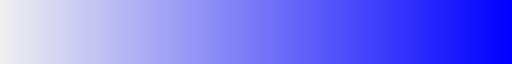

In [118]:
import seaborn as sns
cm=sns.light_palette('blue',as_cmap=True)
cm

In [119]:
pivot_df.style.background_gradient(cmap=cm)

In [122]:
pivot_df.style.set_table_styles([{'selector':'',
                                 'props':[('border','5px solid green')]
                                 }]
                               )
#set_table_styles takes a list of dictionary
##
#

In [123]:
df3.head().style.set_properties(**{'border':'3px solid green',
                                  'color':'red'})

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.000000,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wireless Headset System,2309.650000,7,0.000000,762.184500,933.570000,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,nan,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395000,9,0.100000,-288.765000,923.630000,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,nan,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171000,9,0.100000,919.971000,915.490000,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,nan,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510000,5,0.100000,-96.540000,910.160000,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,nan,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960000,8,0.000000,311.520000,903.040000,Critical


In [124]:
df3.head().style.hide(['Order ID','Sub-Category'],
                    axis=1)

,Row ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.000000,US,East,TEC-AC-10003033,Technology,Plantronics CS510 - Over-the-Head monaural Wireless Headset System,2309.650000,7,0.000000,762.184500,933.570000,Critical
1,26341,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,nan,APAC,Oceania,FUR-CH-10003950,Furniture,"Novimex Executive Leather Armchair, Black",3709.395000,9,0.100000,-288.765000,923.630000,Critical
2,25330,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,nan,APAC,Oceania,TEC-PH-10004664,Technology,"Nokia Smart Phone, with Caller ID",5175.171000,9,0.100000,919.971000,915.490000,Medium
3,13524,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,nan,EU,Central,TEC-PH-10004583,Technology,"Motorola Smart Phone, Cordless",2892.510000,5,0.100000,-96.540000,910.160000,Medium
4,47221,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,nan,Africa,Africa,TEC-SHA-10000501,Technology,"Sharp Wireless Fax, High-Speed",2832.960000,8,0.000000,311.520000,903.040000,Critical


In [125]:
pivot_df.style.hide(['Canada','Africa'],
                   axis=0)

In [127]:
df_700=df3.loc[df3['Sales']>=700, ['Category','Sub-Category','Sales']]
df_700.head()

,Category,Sub-Category,Sales
0,Technology,Accessories,2309.650
1,Furniture,Chairs,3709.395
2,Technology,Phones,5175.171
3,Technology,Phones,2892.510
4,Technology,Copiers,2832.960


In [129]:
df_700.shape

(4460, 3)

In [130]:
# find the sales between 700 and 900 for technology

sales_700_900 = df3.loc[(df3['Sales'] >=700) & (df3['Sales'] <= 900) & (df3['Category'] == 'Technology')]
sales_700_900.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
321,2397,MX-2014-113845,2014-09-12,2014-09-14,First Class,CS-12460,Chuck Sachs,Consumer,Managua,Managua,...,TEC-PH-10002815,Technology,Phones,"Samsung Smart Phone, VoIP",848.320,2,0.00,110.280,351.067,Critical
364,14419,ES-2014-5554891,2014-06-27,2014-06-27,Same Day,CC-12100,Chad Cunningham,Home Office,Grenoble,Rhône-Alpes,...,TEC-CO-10004567,Technology,Copiers,"Brother Fax Machine, Color",815.949,3,0.15,287.919,333.020,Critical
422,21510,IN-2013-15277,2013-11-11,2013-11-11,Same Day,MR-17545,Mathew Reese,Home Office,Jodhpur,Rajasthan,...,TEC-CO-10002150,Technology,Copiers,"Canon Fax and Copier, Digital",763.920,4,0.00,381.960,313.660,Critical
480,29718,IN-2011-51740,2011-08-03,2011-08-06,Second Class,DM-13525,Don Miller,Corporate,Muzaffarpur,Bihar,...,TEC-PH-10000720,Technology,Phones,"Samsung Audio Dock, Full Size",840.600,5,0.00,319.350,296.680,Critical
487,7054,MX-2014-127005,2014-11-11,2014-11-14,First Class,LS-17245,Lynn Smith,Consumer,Zapopan,Jalisco,...,TEC-PH-10000018,Technology,Phones,"Nokia Smart Phone, Full Size",849.800,2,0.00,195.440,294.566,Critical


In [132]:
# to find the product name whose length is greater than 100 characters

prodName100 = df3.loc[df3['Product Name'].str.len() > 100]
prodName100.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
3031,37695,CA-2014-151981,2014-08-07,2014-08-13,Standard Class,GM-14455,Gary Mitchum,Home Office,Concord,New Hampshire,...,TEC-PH-10003601,Technology,Phones,Ativa D5772 2-Line 5.8GHz Digital Expandable C...,824.950,5,0.0,247.4850,99.10,Medium
5675,40195,CA-2012-163237,2012-08-07,2012-08-09,Second Class,EM-14095,Eudokia Martin,Corporate,Springfield,Virginia,...,TEC-PH-10003601,Technology,Phones,Ativa D5772 2-Line 5.8GHz Digital Expandable C...,494.970,3,0.0,148.4910,59.41,High
6467,38150,US-2014-162670,2014-12-24,2014-12-29,Second Class,MF-18250,Monica Federle,Corporate,Little Rock,Arkansas,...,TEC-PH-10003601,Technology,Phones,Ativa D5772 2-Line 5.8GHz Digital Expandable C...,494.970,3,0.0,148.4910,52.69,Medium
15888,31487,CA-2012-102281,2012-10-12,2012-10-14,First Class,MP-17470,Mark Packer,Home Office,New York City,New York,...,TEC-PH-10001552,Technology,Phones,I Need's 3d Hello Kitty Hybrid Silicone Case C...,71.760,6,0.0,20.0928,18.15,Critical
23016,40204,CA-2013-139934,2013-12-19,2013-12-21,First Class,AY-10555,Andy Yotov,Corporate,San Francisco,California,...,TEC-PH-10001552,Technology,Phones,I Need's 3d Hello Kitty Hybrid Silicone Case C...,66.976,7,0.2,6.6976,9.66,Medium


In [133]:
prodName100.shape

(14, 24)

In [135]:
# exlucing state names
# exclude names California and New York

excludeStates = df3.loc[~((df3['State'] == 'New York') | (df3['State'] == 'California'))]
excludeStates.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.765,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.971,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.540,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.520,903.04,Critical
5,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,TEC-PH-10000030,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862.675,5,0.1,763.275,897.35,Critical


In [136]:
# using query method to filter

df3.query("State != ['Queensland','Berlin']")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.570,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.630,Critical
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.040,Critical
5,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,TEC-PH-10000030,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862.675,5,0.1,763.2750,897.350,Critical
6,30570,IN-2011-81826,2011-11-07,2011-11-09,First Class,TS-21340,Toby Swindell,Consumer,Porirua,Wellington,...,FUR-CH-10004050,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable",1822.080,4,0.0,564.8400,894.770,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2014-62366,2014-06-19,2014-06-19,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.010,Medium
51286,35398,US-2014-102288,2014-06-20,2014-06-24,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.010,Medium
51287,40470,US-2013-155768,2013-12-02,2013-12-02,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.010,High
51288,9596,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.003,Medium


In [137]:
# filter sales between 100 and 200 with category starting from F
# can also try df.loc method
df3.query('Sales>=100 & Sales<300 & Category.str.startswith("F")')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
2083,10551,IT-2013-3376681,2013-08-31,2013-09-03,First Class,KC-16675,Kimberly Carter,Corporate,Celle,Lower Saxony,...,FUR-CH-10000399,Furniture,Chairs,"Hon Swivel Stool, Set of Two",298.620,2,0.1,46.4400,130.570,Critical
2515,1900,MX-2014-124744,2014-12-17,2014-12-19,First Class,MY-18295,Muhammed Yedwab,Corporate,Matagalpa,Matagalpa,...,FUR-BO-10001739,Furniture,Bookcases,"Dania Classic Bookcase, Mobile",275.520,1,0.0,49.5800,113.009,Critical
2517,20118,ES-2012-3424900,2012-09-13,2012-09-15,First Class,NS-18505,Neola Schneider,Consumer,Coventry,England,...,FUR-FU-10004608,Furniture,Furnishings,"Advantus Door Stop, Erganomic",274.995,9,0.3,3.9150,112.980,Critical
2723,33418,CA-2014-158246,2014-11-10,2014-11-12,First Class,JB-15400,Jennifer Braxton,Corporate,Sunnyvale,California,...,FUR-CH-10003061,Furniture,Chairs,"Global Leather Task Chair, Black",215.976,3,0.2,-2.6997,106.810,Critical
2812,48448,IR-2013-390,2013-03-22,2013-03-22,Same Day,JG-5160,James Galang,Consumer,Kazerun,Fars,...,FUR-HON-10004137,Furniture,Chairs,"Hon Rocking Chair, Set of Two",265.740,2,0.0,77.0400,104.590,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48684,19590,IT-2011-2536577,2011-01-26,2011-01-29,Second Class,AS-10240,Alan Shonely,Consumer,Montpellier,Languedoc-Roussillon,...,FUR-FU-10002557,Furniture,Furnishings,"Rubbermaid Stacking Tray, Erganomic",177.360,8,0.0,0.0000,0.610,Medium
49167,24369,IN-2014-65992,2014-11-18,2014-11-22,Standard Class,Co-12640,Corey-Lock,Consumer,Bangalore,Karnataka,...,FUR-FU-10001351,Furniture,Furnishings,"Rubbermaid Photo Frame, Black",155.250,3,0.0,24.8400,0.520,Medium
49334,27891,IN-2012-64221,2012-07-05,2012-07-07,First Class,AO-10810,Anthony O'Donnell,Corporate,Ludhiana,Punjab,...,FUR-FU-10000921,Furniture,Furnishings,"Advantus Door Stop, Erganomic",130.950,3,0.0,11.7000,0.490,Medium
50176,1183,MX-2014-167493,2014-11-13,2014-11-17,Standard Class,MY-18295,Muhammed Yedwab,Corporate,Poza Rica de Hidalgo,Veracruz,...,FUR-BO-10003221,Furniture,Bookcases,"Safco Corner Shelving, Mobile",162.112,2,0.2,-10.1680,0.334,Medium


In [139]:
# filter customer names leading character Ad
# basically the name that starts with Ad , like Adam, etc

df3[df3['Customer Name'].str.startswith("Ad")][['Customer Name','State','Sales']]

,Customer Name,State,Sales
106,Adam Bellavance,Washington,2036.860
107,Adam Bellavance,Antioquia,2472.660
122,Adrian Barton,Michigan,9892.740
233,Adam Bellavance,Western Cape,1237.560
250,Adrian Barton,Kerala,1066.680
...,...,...,...
50754,Adam Bellavance,Indiana,4.410
50809,Adam Shillingsburg,Rabat-Salé-Zemmour-Zaer,9.840
50867,Adrian Shami,Washington,4.180
50895,Adrian Hane,Pavlodar,2.052


In [140]:
# find customer names who has ea in their names

df3[df3['Customer Name'].str.contains("ea")].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
141,17765,IT-2013-1350483,2013-09-05,2013-09-07,Second Class,SB-20290,Sean Braxton,Corporate,Treviso,Veneto,...,TEC-CO-10003800,Technology,Copiers,"Hewlett Wireless Fax, Color",2671.410,7,0.0,534.240,483.04,High
160,22058,IN-2013-17041,2013-10-02,2013-10-04,First Class,SO-20335,Sean O'Donnell,Consumer,Changchun,Jilin,...,OFF-AP-10002090,Office Supplies,Appliances,"Hamilton Beach Refrigerator, Red",3000.780,6,0.0,1080.180,465.63,High
216,11073,ES-2013-4632541,2013-09-27,2013-09-27,Same Day,SC-20305,Sean Christensen,Consumer,Benidorm,Valenciana,...,FUR-BO-10002708,Furniture,Bookcases,"Dania Library with Doors, Pine",1091.250,3,0.0,119.970,411.64,Critical
254,21667,ID-2013-17055,2013-08-24,2013-08-26,Second Class,HJ-14875,Heather Jas,Home Office,Luoyang,Henan,...,FUR-TA-10002153,Furniture,Tables,"Lesro Round Table, with Bottom Storage",2214.849,7,0.3,-221.571,382.10,Critical
257,31559,US-2011-106992,2011-09-19,2011-09-21,Second Class,SB-20290,Sean Braxton,Corporate,Houston,Texas,...,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,3059.982,3,0.4,-509.997,380.77,Medium


In [142]:

df3.loc[~(df3['Customer Name'].str.startswith("A"))].sort_values(by='Customer Name')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
26516,46539,SF-2011-7990,2011-12-06,2011-12-08,Second Class,BF-975,Barbara Fisher,Corporate,Pretoria,Gauteng,...,FUR-BUS-10002192,Furniture,Bookcases,"Bush 3-Shelf Cabinet, Metal",142.8300,1,0.000,41.4000,7.28,High
13544,24992,ID-2013-78795,2013-07-22,2013-07-29,Standard Class,BF-10975,Barbara Fisher,Corporate,Newcastle,New South Wales,...,FUR-BO-10003913,Furniture,Bookcases,"Safco Stackable Bookrack, Pine",270.5940,2,0.100,-0.0060,22.68,Low
5933,31174,IN-2014-80629,2014-11-26,2014-11-29,Second Class,BF-10975,Barbara Fisher,Corporate,Auckland,Auckland,...,FUR-TA-10003583,Furniture,Tables,"Lesro Computer Table, with Bottom Storage",516.6360,2,0.400,-155.0040,56.98,High
41901,45429,SU-2013-4590,2013-03-26,2013-03-31,Standard Class,BF-975,Barbara Fisher,Corporate,Ad Diwem,White Nile,...,OFF-SAN-10000844,Office Supplies,Paper,"SanDisk Parchment Paper, Recycled",33.2400,2,0.000,5.2800,1.84,Medium
17826,49785,EG-2012-8860,2012-11-07,2012-11-09,Second Class,BF-975,Barbara Fisher,Corporate,Alexandria,Al Iskandariyah,...,OFF-CAR-10004661,Office Supplies,Binders,"Cardinal Binding Machine, Recycled",100.2600,2,0.000,21.0000,15.19,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2727,2175,MX-2014-168550,2014-06-18,2014-06-21,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,Madero,Tamaulipas,...,TEC-CO-10002271,Technology,Copiers,"Sharp Fax Machine, Laser",590.1174,3,0.002,69.7374,106.68,Critical
18475,15733,ES-2014-5329048,2014-12-30,2015-01-04,Standard Class,ZD-21925,Zuschuss Donatelli,Consumer,Rouen,Upper Normandy,...,FUR-BO-10004914,Furniture,Bookcases,"Bush 3-Shelf Cabinet, Traditional",129.0330,1,0.100,17.1930,14.29,Medium
23733,2632,MX-2012-105662,2012-11-26,2012-12-03,Standard Class,ZD-21925,Zuschuss Donatelli,Consumer,Toluca,México,...,FUR-FU-10001410,Furniture,Furnishings,"Tenex Frame, Black",87.9840,2,0.400,7.3040,9.11,Low
41488,34337,US-2013-147991,2013-05-06,2013-05-10,Standard Class,ZD-21925,Zuschuss Donatelli,Consumer,Chattanooga,Tennessee,...,FUR-FU-10004270,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",16.7200,5,0.200,3.3440,1.93,High


In [146]:
df_book = pd.read_csv(r'C:\Users\Futurense\Downloads\Marvel_Comics.csv')
df_book.head(10)

,comic_name,active_years,issue_title,publish_date,issue_description,penciler,writer,cover_artist,Imprint,Format,Rating,Price
0,A Year of Marvels: April Infinite Comic (2016),(2016),A Year of Marvels: April Infinite Comic (2016) #1,"April 01, 2016",The Infinite Comic that will have everyone tal...,Yves Bigerel,Yves Bigerel,Jamal Campbell,Marvel Universe,Infinite Comic,Rated T+,Free
1,A Year of Marvels: August Infinite Comic (2016),(2016),A Year of Marvels: August Infinite Comic (2016...,"August 10, 2016","It’s August, and Nick Fury is just in time to ...",Jamal Campbell,"Chris Sims, Chad Bowers",None,Marvel Universe,Infinite Comic,None,Free
2,A Year of Marvels: February Infinite Comic (2016),(2016),A Year of Marvels: February Infinite Comic (20...,"February 10, 2016",Join us in a brand new Marvel comics adventure...,"Danilo S. Beyruth, M Mast",Ryan North,None,Marvel Universe,Infinite Comic,Rated T+,Free
3,A Year of Marvels: July Infinite Comic (2016),(2016),A Year of Marvels: July Infinite Comic (2016) #1,"June 29, 2016",Celebrating the Fourth of July is complicated ...,Juanan Ramirez,Chuck Wendig,Jamal Campbell,Marvel Universe,Infinite Comic,None,Free
4,A Year of Marvels: June Infinite Comic (2016),(2016),A Year of Marvels: June Infinite Comic (2016) #1,"June 15, 2016",Sam Alexander’s finding it hard to cope with t...,Diego Olortegui,Paul Allor,Jamal Campbell,Marvel Universe,Infinite Comic,None,Free
5,A Year of Marvels: March Infinite Comic (2016),(2016),A Year of Marvels: March Infinite Comic (2016) #1,"March 09, 2016","When business is down in March, Scott Lang’s A...",Ryan Browne,Amy Chu,Jamal Campbell,Marvel Universe,Infinite Comic,None,Free
6,A Year of Marvels: May Infinite Comic (2016),(2016),A Year of Marvels: May Infinite Comic (2016) #1,"May 04, 2016",Presenting: A Mother’s Day story to curdle to ...,Leonardo Romero,Dennis Culver,Jamal Campbell,Marvel Universe,Infinite Comic,None,Free
7,A Year of Marvels: November Infinite Comic (2016),(2016),A Year of Marvels: November Infinite Comic (20...,"November 23, 2016",It’s time to give thanks for…THE PUNISHER?! Wh...,Paul Davidson,"Elliott Casey, Todd Casey",Jamal Campbell,Marvel Universe,Infinite Comic,None,Free
8,A Year of Marvels: October Infinite Comic (2016),(2016),A Year of Marvels: October Infinite Comic (201...,"October 26, 2016",It’s Halloween in the Marvel U! What does that...,Laura Braga,Jeremy Whitley,Jamal Campbell,Marvel Universe,Infinite Comic,None,Free
9,A Year of Marvels: September Infinite Comic (2...,(2016),A Year of Marvels: September Infinite Comic (2...,"September 07, 2016","In September, TIPPY-TOE is flying SOLO (until ...",Siya Oum,Nilah Magruder,Jamal Campbell,Marvel Universe,Infinite Comic,None,Free


In [147]:
#04-04-2023

In [148]:
import datetime

In [149]:
d=datetime.date(2023,2,21) #yyyy-mm-dd
d
#zero padding is not allowed


datetime.date(2023, 2, 21)

In [150]:
tday=datetime.date.today()

In [151]:
tday

datetime.date(2023, 4, 4)

In [152]:
print(tday)

2023-04-04


In [153]:
print(tday.weekday()) #monday=0 and Tuesday=1 and sunday=6


1


In [154]:
print(tday.isoweekday()) 
#monday=1 and sunday is 7 #following global trending and financial analysis

2


In [155]:
print(tday.year)
print(tday.day) #date on today

2023
4


In [156]:
t_delta=datetime.timedelta(days=10) #tells whats the difference between two days
t_delta

datetime.timedelta(days=10)

In [157]:
print(tday+t_delta) #gives the date after 10days

2023-04-14


In [158]:
print(tday-t_delta) #date before 10 days from now

2023-03-25


In [ ]:
#how to get next business day

In [164]:
tday1=datetime.datetime.now()
tday1

datetime.datetime(2023, 4, 4, 11, 10, 58, 196090)

In [166]:
print(tday1.tzinfo)

None


In [167]:
aug_15=datetime.date(2023,8,15)
aug_15

datetime.date(2023, 8, 15)

In [169]:
#no of days between today and independence day
time_diff=aug_15-tday
time_diff

datetime.timedelta(days=133)

In [170]:
#no of days between today and my birth day
bday=datetime.date(2023,4,11)
bday_diff=bday-tday
bday_diff

datetime.timedelta(days=7)

In [172]:
t=datetime.time(12,30,25,12500)
print(t)

12:30:25.012500


In [173]:
print(t.hour)
print(t.minute)
print(t.second)

12
30
25


In [174]:
dt=datetime.datetime(2023,2,21,17,23,25,10400)
dt

datetime.datetime(2023, 2, 21, 17, 23, 25, 10400)

In [175]:
print(dt.year)
print(dt.minute)
print(dt.hour)

2023
23
17


In [176]:
time_delta=datetime.timedelta(days=7,hours=3)
print(dt+time_delta)

2023-02-28 20:23:25.010400


In [177]:
today=datetime.datetime.now()
print(today)

2023-04-04 11:28:05.618102


In [178]:
print(type(today))

<class 'datetime.datetime'>


In [181]:
today=datetime.datetime.now()
print(today)

2023-04-04 11:35:17.637471


In [183]:
dt_utcnow=datetime.datetime.utcnow()
print(dt_utcnow)

2023-04-04 06:06:15.725444


In [184]:
import pytz

In [185]:
utc = pytz.utc
utc

<UTC>

In [187]:
dt=datetime.datetime(2023,2,12,13,12,13,20200,tzinfo=pytz.UTC)
print(dt)

2023-02-12 13:12:13.020200+00:00


In [188]:
dt_now=datetime.datetime.now(tz=pytz.UTC)
print(dt_now)

2023-04-04 06:38:49.932673+00:00


In [190]:
pip install pytz

Note: you may need to restart the kernel to use updated packages.


In [192]:
from dateutil import tz
to_zone=tz.tzlocal() #to extract the local timezone
print(to_zone)

tzlocal()


In [193]:
#convert UTC timezone to IST zone
dt_IST=dt_utcnow.astimezone(to_zone)  #astimezone is a method 
print(dt_IST)
#wiki link:  https://en.wikipedia.org/wiki/Indian_Standard_Time

2023-04-04 06:06:15.725444+05:30


In [194]:
for i in pytz.all_timezones:
    print(i)

Africa/Abidjan
Africa/Accra
Africa/Addis_Ababa
Africa/Algiers
Africa/Asmara
Africa/Asmera
Africa/Bamako
Africa/Bangui
Africa/Banjul
Africa/Bissau
Africa/Blantyre
Africa/Brazzaville
Africa/Bujumbura
Africa/Cairo
Africa/Casablanca
Africa/Ceuta
Africa/Conakry
Africa/Dakar
Africa/Dar_es_Salaam
Africa/Djibouti
Africa/Douala
Africa/El_Aaiun
Africa/Freetown
Africa/Gaborone
Africa/Harare
Africa/Johannesburg
Africa/Juba
Africa/Kampala
Africa/Khartoum
Africa/Kigali
Africa/Kinshasa
Africa/Lagos
Africa/Libreville
Africa/Lome
Africa/Luanda
Africa/Lubumbashi
Africa/Lusaka
Africa/Malabo
Africa/Maputo
Africa/Maseru
Africa/Mbabane
Africa/Mogadishu
Africa/Monrovia
Africa/Nairobi
Africa/Ndjamena
Africa/Niamey
Africa/Nouakchott
Africa/Ouagadougou
Africa/Porto-Novo
Africa/Sao_Tome
Africa/Timbuktu
Africa/Tripoli
Africa/Tunis
Africa/Windhoek
America/Adak
America/Anchorage
America/Anguilla
America/Antigua
America/Araguaina
America/Argentina/Buenos_Aires
America/Argentina/Catamarca
America/Argentina/ComodRivad

In [ ]:
#date range and period range

In [196]:
dateRange=pd.date_range(start='2023-3-24',end='2023-4-10')

In [197]:
dateRange

DatetimeIndex(['2023-03-24', '2023-03-25', '2023-03-26', '2023-03-27',
               '2023-03-28', '2023-03-29', '2023-03-30', '2023-03-31',
               '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04',
               '2023-04-05', '2023-04-06', '2023-04-07', '2023-04-08',
               '2023-04-09', '2023-04-10'],
              dtype='datetime64[ns]', freq='D')

In [198]:
type(dateRange)

pandas.core.indexes.datetimes.DatetimeIndex

In [199]:
dateRange1=pd.date_range(start='2023-3-24',end='2023-10-10',freq='M')
dateRange1

DatetimeIndex(['2023-03-31', '2023-04-30', '2023-05-31', '2023-06-30',
               '2023-07-31', '2023-08-31', '2023-09-30'],
              dtype='datetime64[ns]', freq='M')

In [201]:
pd.date_range(start='2023-2-12',periods=3,freq='2M') #only start is needed 

DatetimeIndex(['2023-02-28', '2023-04-30', '2023-06-30'], dtype='datetime64[ns]', freq='2M')

In [203]:
pd.date_range(start='2023-1-12', periods=6, tz='Asia/Tokyo')
#daterange based on asia tokyo time zone

DatetimeIndex(['2023-01-12 00:00:00+09:00', '2023-01-13 00:00:00+09:00',
               '2023-01-14 00:00:00+09:00', '2023-01-15 00:00:00+09:00',
               '2023-01-16 00:00:00+09:00', '2023-01-17 00:00:00+09:00'],
              dtype='datetime64[ns, Asia/Tokyo]', freq='D')

In [208]:
#frequency in hours
pd.date_range(start='2023-2-12',periods=12,freq='H')

DatetimeIndex(['2023-02-12 00:00:00', '2023-02-12 01:00:00',
               '2023-02-12 02:00:00', '2023-02-12 03:00:00',
               '2023-02-12 04:00:00', '2023-02-12 05:00:00',
               '2023-02-12 06:00:00', '2023-02-12 07:00:00',
               '2023-02-12 08:00:00', '2023-02-12 09:00:00',
               '2023-02-12 10:00:00', '2023-02-12 11:00:00'],
              dtype='datetime64[ns]', freq='H')

In [209]:

pd.date_range(start='2023-2-12',periods=12,freq='S')

DatetimeIndex(['2023-02-12 00:00:00', '2023-02-12 00:00:01',
               '2023-02-12 00:00:02', '2023-02-12 00:00:03',
               '2023-02-12 00:00:04', '2023-02-12 00:00:05',
               '2023-02-12 00:00:06', '2023-02-12 00:00:07',
               '2023-02-12 00:00:08', '2023-02-12 00:00:09',
               '2023-02-12 00:00:10', '2023-02-12 00:00:11'],
              dtype='datetime64[ns]', freq='S')

In [210]:
#period range
pd.period_range(start='2023-2-12',freq='Y',periods=12)

PeriodIndex(['2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030',
             '2031', '2032', '2033', '2034'],
            dtype='period[A-DEC]')

In [211]:
pd.period_range(start='2023-1-2',freq='Q',periods=12) #getting quarters

PeriodIndex(['2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2',
             '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4'],
            dtype='period[Q-DEC]')

In [212]:
pd.period_range(start='2023-2-1',freq='M',periods=10) #getting months

PeriodIndex(['2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07',
             '2023-08', '2023-09', '2023-10', '2023-11'],
            dtype='period[M]')

In [4]:
pd.period_range(start=pd.Period('2023Q3',freq='Q'),
               end=pd.Period('2023Q4',freq='Q'),
                freq='M'
               )

PeriodIndex(['2023-09', '2023-10', '2023-11', '2023-12'], dtype='period[M]')

In [214]:
pd.period_range(start='2023-4-1',
               end='2023-5-1',
                freq='W',
                name='WeekWiseFrequency'
               ) #monday to sunday i.e. 27 Mar to 2 Apr is week1

PeriodIndex(['2023-03-27/2023-04-02', '2023-04-03/2023-04-09',
             '2023-04-10/2023-04-16', '2023-04-17/2023-04-23',
             '2023-04-24/2023-04-30', '2023-05-01/2023-05-07'],
            dtype='period[W-SUN]', name='WeekWiseFrequency')

In [219]:
#generate frequency on month range
monthRange = pd.date_range(start = "2022-1-1", 
                          periods = 12,
                          freq = 'M')

for month in monthRange:
    print(month.month,month.days_in_month, month.month_name())

1 31 January
2 28 February
3 31 March
4 30 April
5 31 May
6 30 June
7 31 July
8 31 August
9 30 September
10 31 October
11 30 November
12 31 December


In [220]:
# date range based on buisness days

pd.date_range(start = "2023-1-1",
             end = "2023-1-31",
             freq = 'B')

# we get the buiness days only
# this output exclues the weekend,i.e, Saturday and Sunday

# you can take a start and end date and then compute the business days accordingly

DatetimeIndex(['2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
               '2023-01-06', '2023-01-09', '2023-01-10', '2023-01-11',
               '2023-01-12', '2023-01-13', '2023-01-16', '2023-01-17',
               '2023-01-18', '2023-01-19', '2023-01-20', '2023-01-23',
               '2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27',
               '2023-01-30', '2023-01-31'],
              dtype='datetime64[ns]', freq='B')

# 5th April 2023

In [1]:
import pandas as pd

In [6]:
import datetime

In [2]:
# every 4th monday
# in some specific month the business wants every 4th monday's date

pd.date_range(start = "2023-1-1",
             end = "2023-9-1",
             freq="WOM-4MON") # WOM : week of Month , 4MON : 4th Monday

# so 4th monday in jan comes on 23rd
# following month feb, 4th Monday comes on 27th ...

DatetimeIndex(['2023-01-23', '2023-02-27', '2023-03-27', '2023-04-24',
               '2023-05-22', '2023-06-26', '2023-07-24', '2023-08-28'],
              dtype='datetime64[ns]', freq='WOM-4MON')

In [9]:
# date from specific month for Monday,Wednesday and Friday

weekdata = "Mon Wed Fri"

# we want only the business days
# bdate_range is business date range

biz_days = pd.bdate_range(start = datetime.datetime(2023,1,31),
                         end = datetime.datetime(2023,2,28),
                         freq = "C",
                         weekmask=weekdata) # freq = "C" equates to Custom Business Days

print(biz_days)

# the output says ; on 1st Feb is Wednesday, 03rd Feb is Friday ...
# we can check it in calendar
# because before 31st January, 30th January is Monday

DatetimeIndex(['2023-02-01', '2023-02-03', '2023-02-06', '2023-02-08',
               '2023-02-10', '2023-02-13', '2023-02-15', '2023-02-17',
               '2023-02-20', '2023-02-22', '2023-02-24', '2023-02-27'],
              dtype='datetime64[ns]', freq='C')


# Charts and visualization

In [10]:
import matplotlib.pyplot as plt
import seaborn as ans

In [11]:
import numpy as np

# Bar Charts

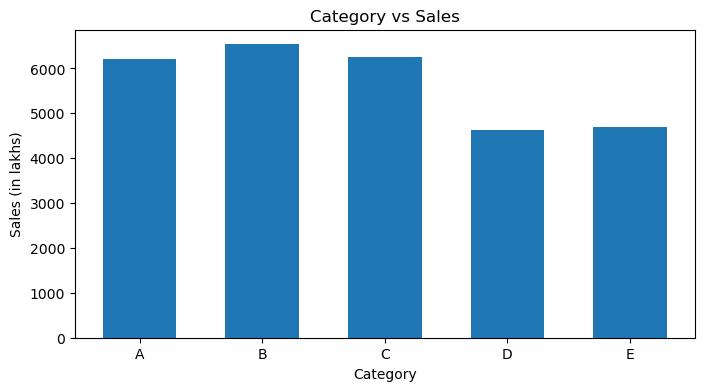

In [22]:
x=['A','B','C','D','E']
y=np.random.randint(low=1000, high=9000,size=5)

plt.subplots(figsize=(8,4))
plt.bar(x,y,width=0.6)
plt.xlabel('Category')
plt.ylabel('Sales (in lakhs)')
plt.title('Category vs Sales')
plt.show()


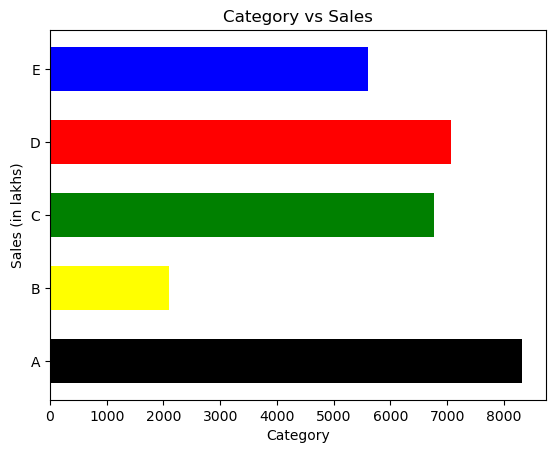

In [21]:
plt.barh(x,y,color=['black','yellow','green','red','blue'],height=.6)
plt.xlabel('Category')
plt.ylabel('Sales (in lakhs)')
plt.title('Category vs Sales')
plt.show()

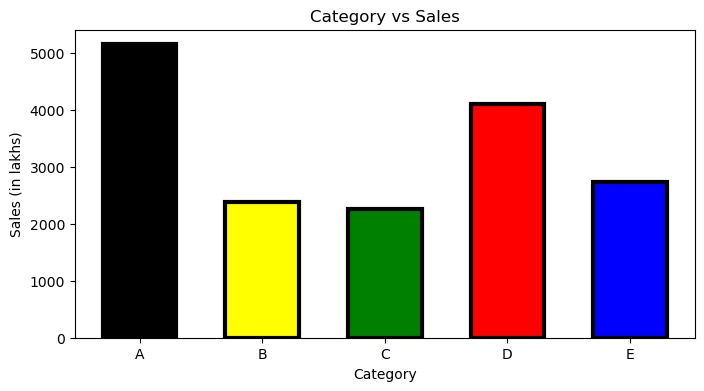

In [25]:
x=['A','B','C','D','E']
y=np.random.randint(low=1000, high=9000,size=5)

plt.subplots(figsize=(8,4))
plt.bar(x,y,width=0.6,edgecolor='black',color=['black','yellow','green','red','blue'],linewidth=3)
plt.xlabel('Category')
plt.ylabel('Sales (in lakhs)')
plt.title('Category vs Sales')
plt.show()


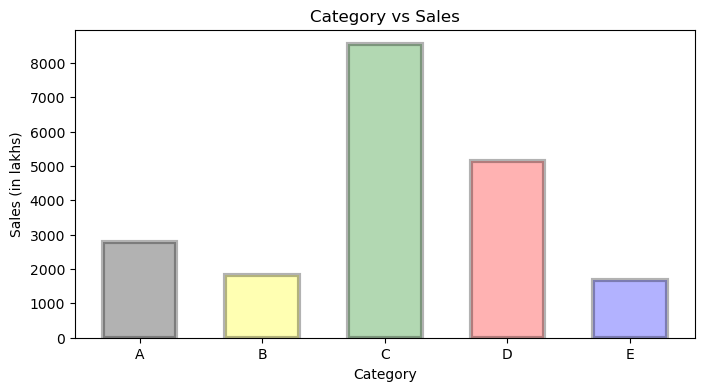

In [26]:
x=['A','B','C','D','E']
y=np.random.randint(low=1000, high=9000,size=5)

plt.subplots(figsize=(8,4))
plt.bar(x,y,width=0.6,alpha=0.3,edgecolor='black',color=['black','yellow','green','red','blue'],linewidth=3)
plt.xlabel('Category')  #alpha gives the transparency of the bar
plt.ylabel('Sales (in lakhs)')
plt.title('Category vs Sales')
plt.show()


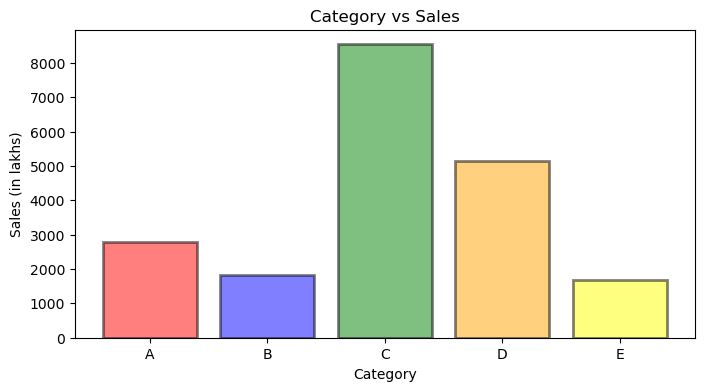

In [29]:
colors = ['red','blue','green','orange','yellow']
edgecolor = 'black'
linewidth = 2
plt.subplots(figsize = (8,4))
plt.bar(x,y,color = colors,edgecolor = edgecolor,linewidth = linewidth, alpha = 0.5)
plt.xlabel('Category')
plt.ylabel('Sales (in lakhs)')
plt.title('Category vs Sales')
plt.show()

In [ ]:
https://matplotlib.org/stable/index.html


In [30]:
#adding data labels
for i,v in enumerate(y):
    print(i,'and',v)

0 and 2782
1 and 1837
2 and 8538
3 and 5130
4 and 1683


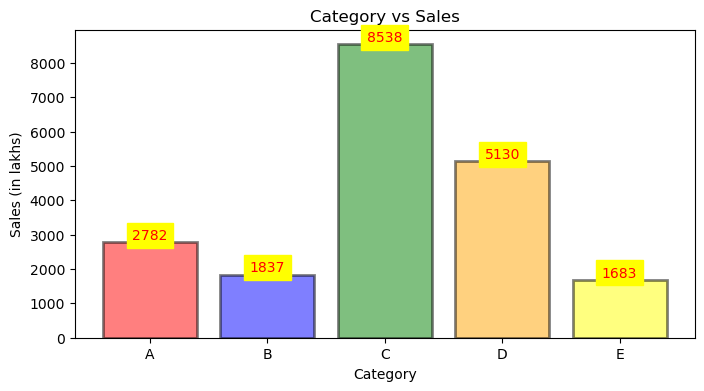

In [34]:
colors = ['red','blue','green','orange','yellow']
edgecolor = 'black'
linewidth = 2
plt.subplots(figsize = (8,4))
plt.bar(x,y,color = colors,edgecolor = edgecolor,linewidth = linewidth, alpha = 0.5)
plt.xlabel('Category')
plt.ylabel('Sales (in lakhs)')
plt.title('Category vs Sales')
for i,v in enumerate(y):
    plt.text(i,v,str(v), color='red',ha='center',va='bottom',backgroundcolor='yellow')
    #ha =horizontal alignment, va -vertical alignment
plt.show()

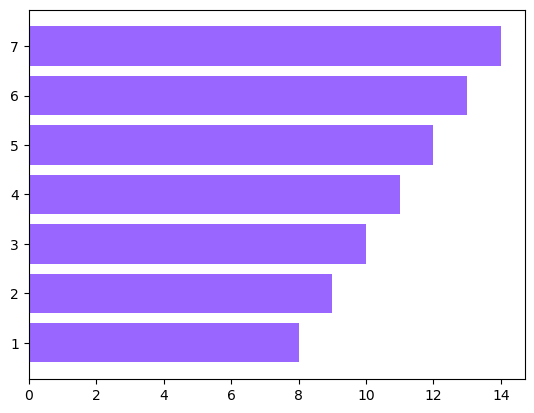

In [35]:
#horizaontal bar plots
x=[1,2,3,4,5,6,7]
y=[8,9,10,11,12,13,14]
plt.barh(x,y,color='#9966FF')
plt.show()

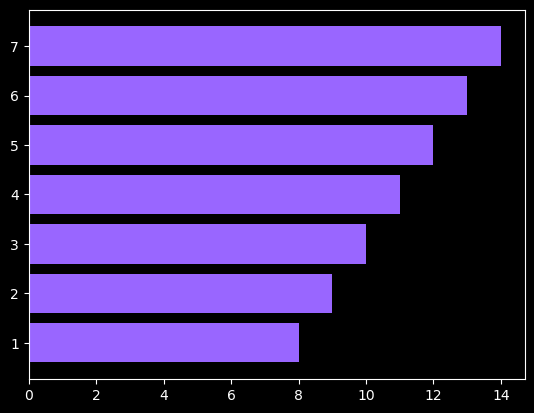

In [38]:
#horizaontal bar plots
plt.style.use('dark_background')
x=[1,2,3,4,5,6,7]
y=[8,9,10,11,12,13,14]
plt.barh(x,y,color='#9966FF')
plt.show()

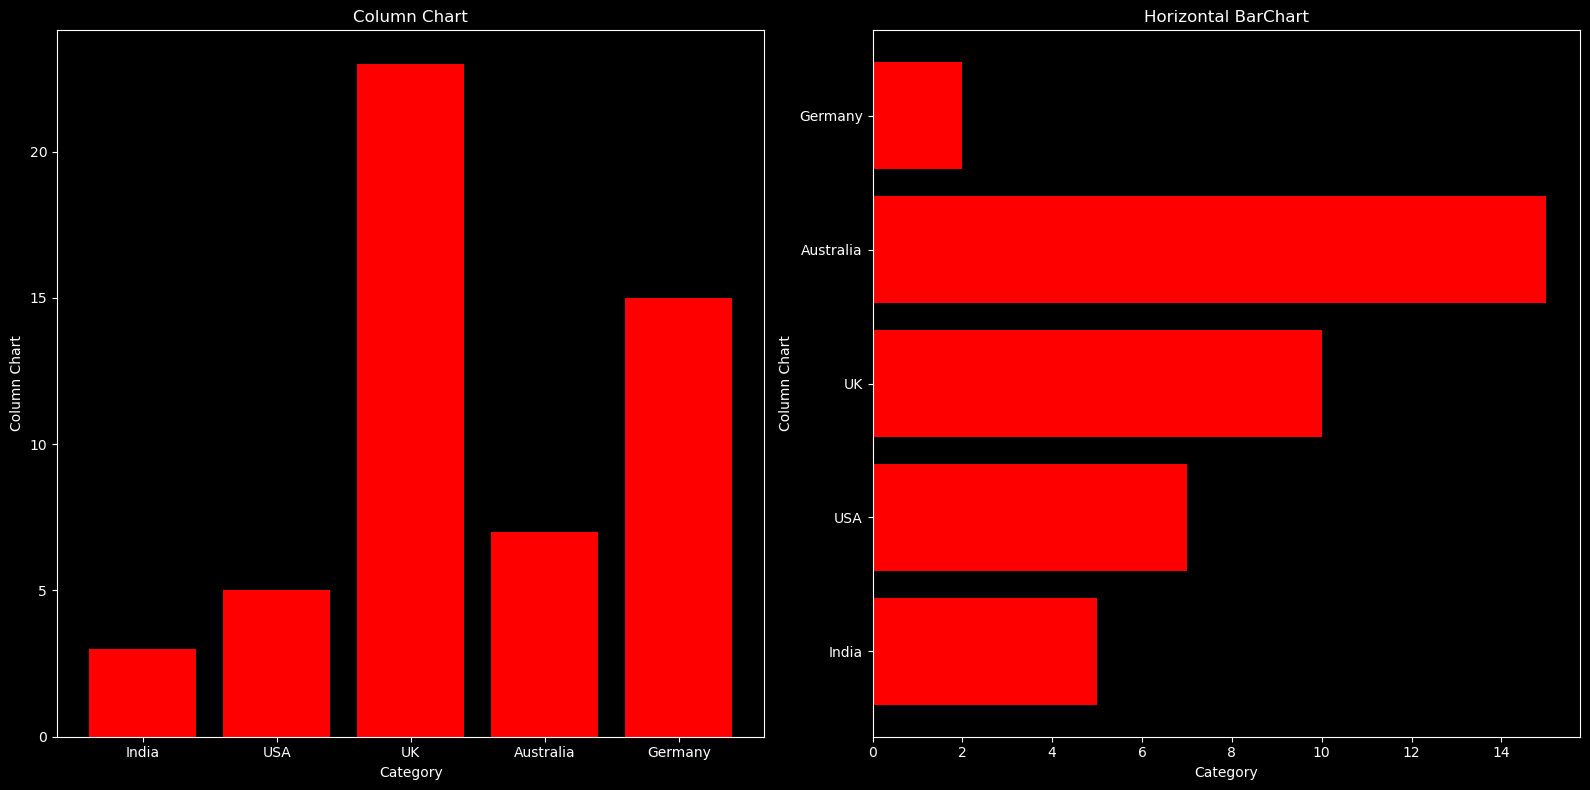

In [40]:
#create column chart and horizontal bar chart together
x=np.array(['India','USA','UK','Australia','Germany'])

y1=[3,5,23,7,15]
y2=[5,7,10,15,2]
fig, (ax1,ax2)=plt.subplots(nrows=1, ncols=2,figsize=(16,8))

ax1.bar(x,y1,color='red')
ax1.set_xlabel('Category')
ax1.set_ylabel('Column Chart')
ax1.set_title('Column Chart')

ax2.barh(x,y2,color='red')
ax2.set_xlabel('Category')
ax2.set_ylabel('Column Chart')
ax2.set_title('Horizontal BarChart')

plt.tight_layout()
plt.show()



# Line chart

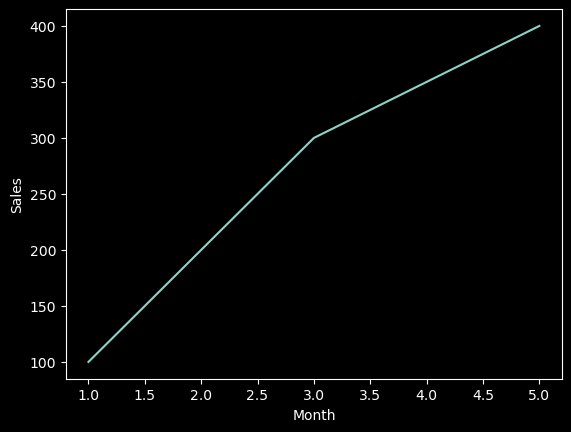

In [41]:
x=[1,2,3,4,5]

y=[100,200,300,350,400]

#create a line chart
plt.plot(x,y)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()


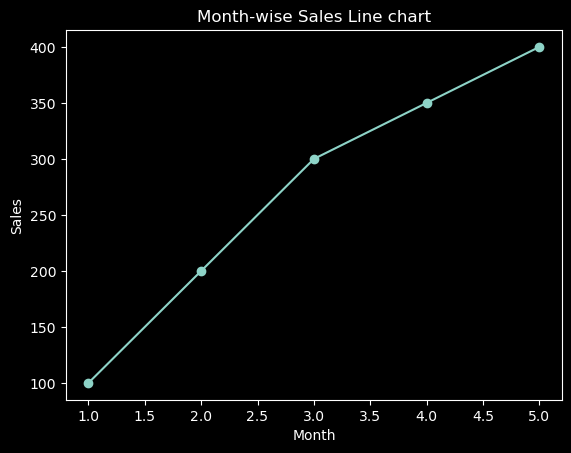

In [42]:
plt.plot(x,y,marker='o')
plt.title('Month-wise Sales Line chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

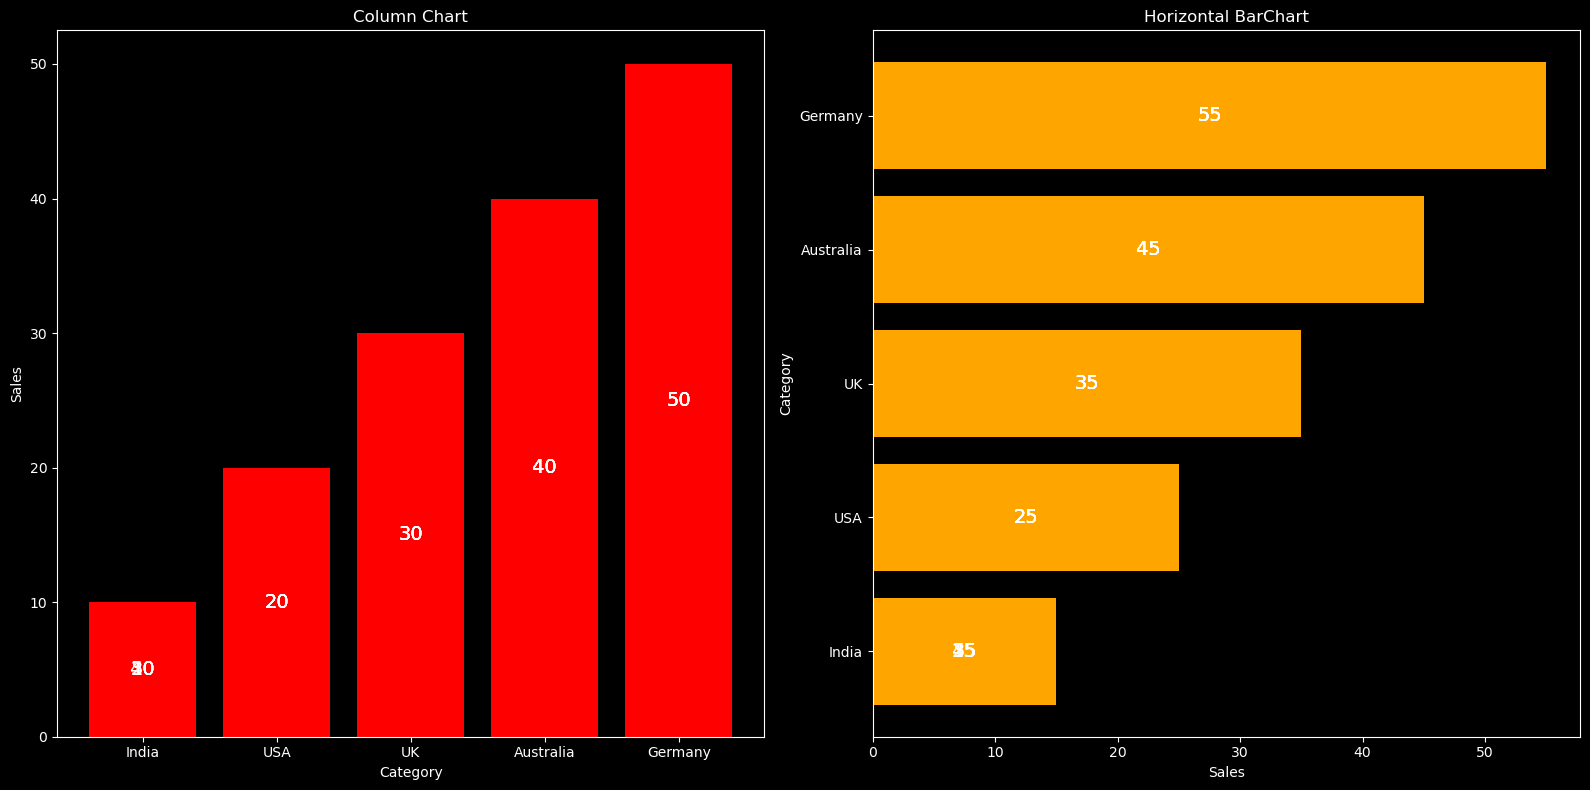

In [44]:
# Create column chart and horizontal bar chart together

x = np.array(['India','USA','UK','Australia','Germany'])

y1 = np.array([10,20,30,40,50])
y2 = np.array([15,25,35,45,55])

#creating figure with 2 subplots
fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(16,8))

ax1.bar(x,y1,color='red')
ax1.set_xlabel('Category')
ax1.set_ylabel('Sales')
ax1.set_title('Column Chart')

ax2.barh(x,y2,color='orange')
ax2.set_xlabel('Sales')
ax2.set_ylabel('Category')
ax2.set_title('Horizontal BarChart')

plt.tight_layout()

for i, v in enumerate(y1):
    ax1.bar_label(ax1.containers[0], labels=[f'{v}'], label_type='center', fontsize=14, color='white')
for i, v in enumerate(y2):
    ax2.bar_label(ax2.containers[0], labels=[f'{v}'], label_type='center', fontsize=14, color='white')
    
plt.show()

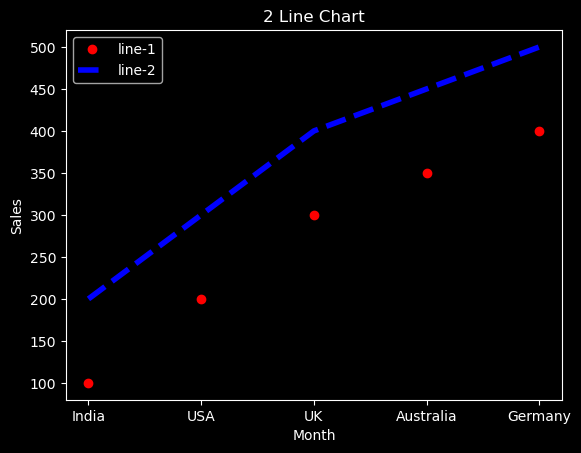

In [49]:
#2 line chart
import matplotlib.pyplot as plt
plt.plot(x,y,'o',color='red',linewidth=2,label='line-1')
plt.plot(x,[200,300,400,450,500],'--',color='blue',linewidth=4,label='line-2')

plt.title('2 Line Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [51]:
df=pd.read_excel(r'C:\Users\Futurense\Downloads\chartsdata.xlsx',sheet_name='sales')
df

,Months,Sales,Profit
0,Jan,100,80
1,Feb,120,60
2,Mar,130,100
3,Apr,140,70
4,May,150,100
5,Jun,170,60
6,Jul,180,85
7,Aug,190,150
8,Sep,200,95
9,Oct,210,100


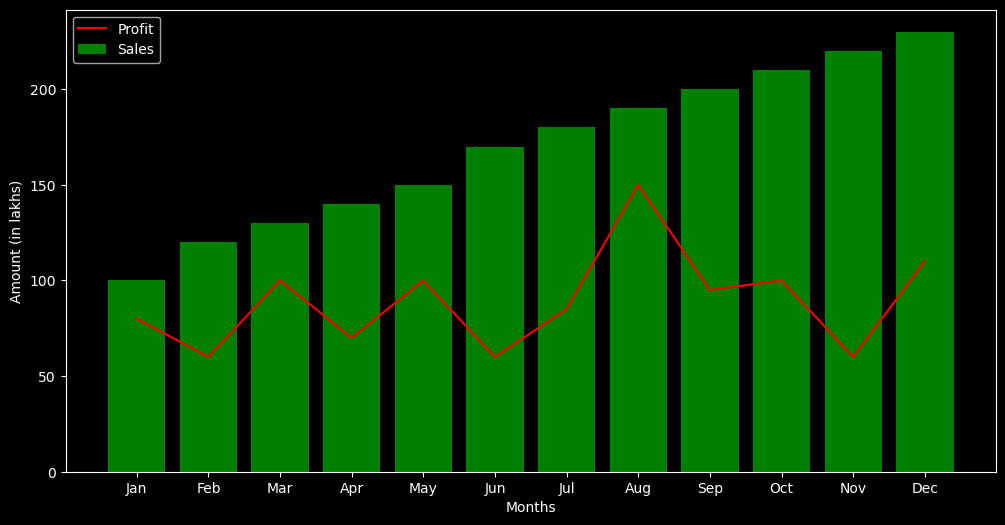

In [52]:
#
fig,ax=plt.subplots(figsize=(12,6))
ax.bar(df['Months'],df['Sales'],color='green',label='Sales')
ax.plot(df['Months'],df['Profit'],color='red',label='Profit')
ax.set_xlabel('Months')
ax.set_ylabel('Amount (in lakhs)')
ax.legend(loc='upper left')
plt.show()



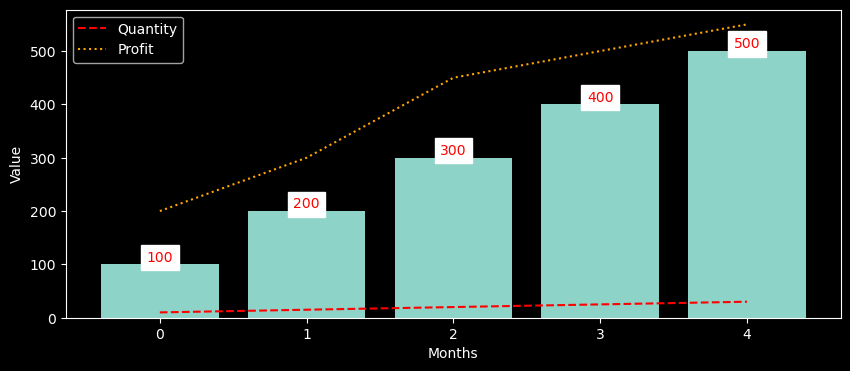

In [55]:
# sales as column chart 
# quantity and profit as line chart

sales = [100,200,300,400,500]
qty = [10,15,20,25,30]
profit=[200,300,450,500,550]

fig,ax = plt.subplots(figsize=(10,4))
ax.bar(np.arange(len(sales)),sales,align='center')

#plot line chart for quantity
ax.plot(np.arange(len(qty)),qty,color='red',linestyle='dashed')

#plot the line chart for  profit
ax.plot(np.arange(len(profit)),profit,color='orange',linestyle='dotted')

#adding labels and annotations
ax.set_xlabel('Months')
ax.set_ylabel('Value')
ax.legend (['Quantity','Profit'])

for i,v in enumerate(sales):
    ax.text(i,v,str(v),ha='center',va='bottom',fontsize='medium',backgroundcolor='white',color='red')

plt.show()

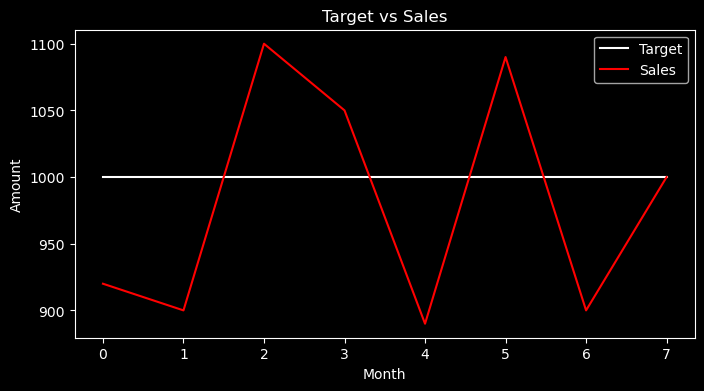

In [59]:
target=1000
plt.subplots(figsize=(8,4))
sales=[920,900,1100,1050,890,1090,900,1000]
plt.plot([target] * len(sales) , label ='Target',color='white')
plt.plot(sales,label='Sales',color='red')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Amount')
plt.title("Target vs Sales")
plt.show()

In [ ]:
fig.ax=plt.subplots(figsize=(16,4))


In [ ]:
100	80
120	60
130	100
140	70
150	100
170	60
180	85
190	150
200	95
210	100
220	60
230	110


In [67]:
df1=pd.read_excel(r'C:\Users\Futurense\Downloads\chartsdata.xlsx',sheet_name='LC1')
df1

,Category,Sales
0,Accessories,1259
1,Appliances,1777
2,Art,1443
3,Binders,1003
4,Bookcases,1722
5,Chairs,1594
6,Copiers,943
7,Furnishings,1520
8,Paper,1791
9,Phones,1768


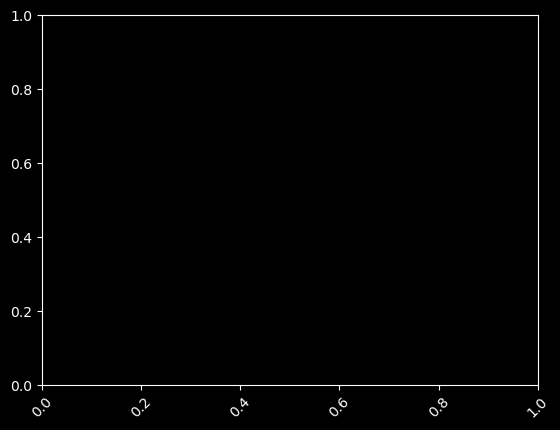

In [68]:
ax.plot(df1['Category'],df1['Sales'],color='red',marker='o',markersize=8,label="Sales",linewidth=2,linestyle='--')
ax.set_title("Sales by Category")
ax.set_xlabel('Category')
ax.set_ylabel('Sales')
ax.legend()
plt.xticks(rotation=45) # will set the tiltness of the variables on x-axis
plt.show()

In [61]:
df2=pd.read_excel(r'C:\Users\Futurense\Downloads\chartsdata.xlsx',sheet_name='LC2')
df2

,Month,East,West,South
0,Jan,1312,1296,1091
1,Feb,1114,933,1492
2,Mar,816,912,1442
3,Apr,975,940,976
4,May,1100,1254,915
5,Jun,1159,1351,953
6,Jul,957,1346,1307
7,Aug,1130,1286,1253
8,Sep,1442,1213,1067
9,Oct,963,802,890


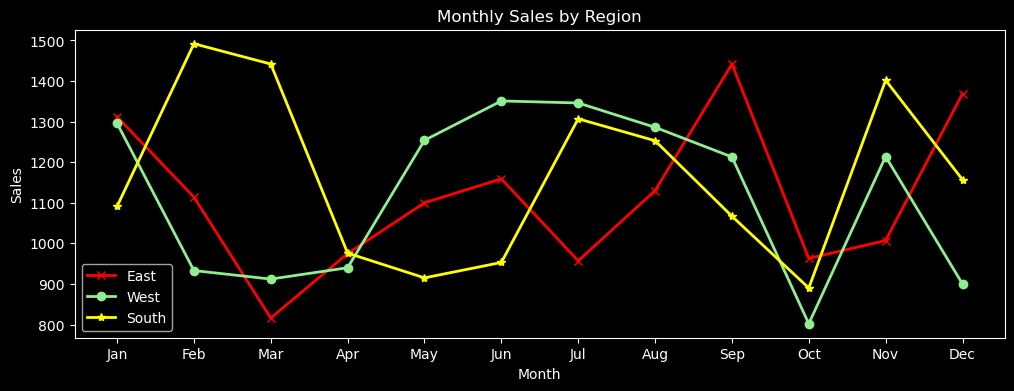

In [62]:
fig,ax = plt.subplots(figsize=(12,4))

ax.plot(df2['Month'], df2['East'], linewidth=2, color='red', marker ='x', markersize=6, label= 'East')
ax.plot(df2['Month'], df2['West'], linewidth=2, color='lightgreen', marker ='o', markersize=6, label= 'West')
ax.plot(df2['Month'], df2['South'], linewidth=2, color='yellow', marker ='*', markersize=6, label= 'South')

ax.set_title("Monthly Sales by Region")
ax.set_xlabel('Month')
ax.set_ylabel('Sales')

plt.xticks()

ax.legend(loc='lower left',fontsize=10)

plt.show()

In [ ]:
https://www.pythonmorsels.com/

In [ ]:
https://aman.ai/

# Pie Charts

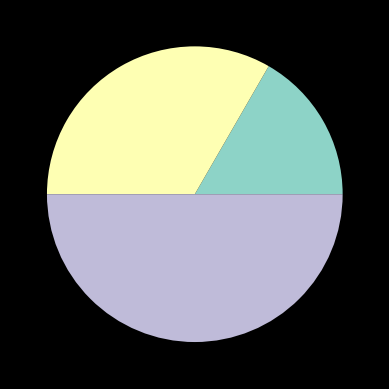

In [65]:
plt.pie([1,2,3])
plt.show()

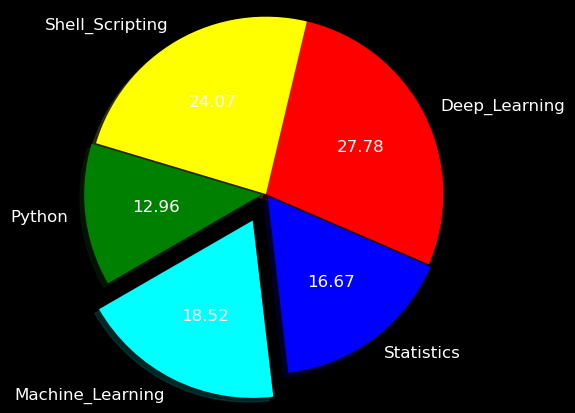

In [66]:
courses = ['Machine_Learning',
          'Statistics',
          'Deep_Learning',
          'Shell_Scripting',
          'Python']

marksObtained = [50,
                45,
                75,
                65,
                35]
# if you want to slice a particular section, use explode
explode = [0.2,0.02,0,0,0.03]

color = ['cyan',
        'blue',
        'red',
        'yellow',
        'green']

plt.pie(marksObtained, labels = courses, 
        explode= explode,
        colors=color,
        autopct = "%0.2f",shadow=True,radius=1.2,textprops={'fontsize': 12},startangle=210) # calculate auto percentage using autopct
# to increase of decrease pie chart you radius
# to rotate the pie chart use startangle
# to increase fontsize use textprops

plt.show()